In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define weights and biases
V = np.array([[-2.69, -2.80],
              [-3.39, -4.56]])      
b_v = np.array([-2.21, -4.76])      
W = np.array([-4.91, 4.95])         
b_w = -2.28                         

# Activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def hard_limit(z):
    return np.where(z >= 0, 1, 0)

def radial_basis(z):
    return np.exp(-(z**2))

# Forward pass
def nn_forward(x1, x2, activation):
    X = np.vstack([x1, x2])                 
    Z_hidden = V @ X + b_v.reshape(-1, 1)   
    H = activation(Z_hidden)                
    y = W @ H + b_w                         
    return y

def plot_surface(n_points, activation, title):
    n_side = int(np.sqrt(n_points))   # points per axis
    x1 = np.linspace(-2, 2, n_side)
    x2 = np.linspace(-2, 2, n_side)
    X1, X2 = np.meshgrid(x1, x2)
    Y = nn_forward(X1.ravel(), X2.ravel(), activation).reshape(X1.shape)

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')

    # Surface with grid edges
    surf = ax.plot_surface(X1, X2, Y, cmap="cividis", edgecolor="k", linewidth=0.3)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    ax.set_title(title)

    # White pane backgrounds
    ax.xaxis.set_pane_color((1, 1, 1, 1))
    ax.yaxis.set_pane_color((1, 1, 1, 1))
    ax.zaxis.set_pane_color((1, 1, 1, 1))

    # Very light grid lines
    ax.xaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1)
    ax.yaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1)
    ax.zaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 1)

    plt.show()




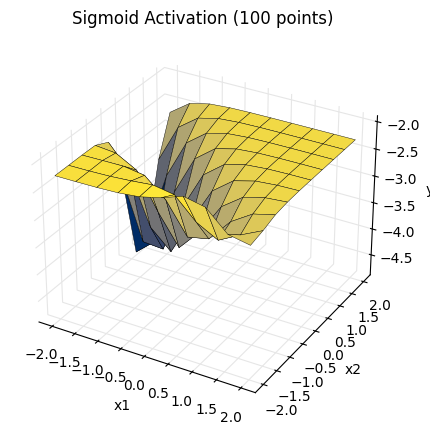

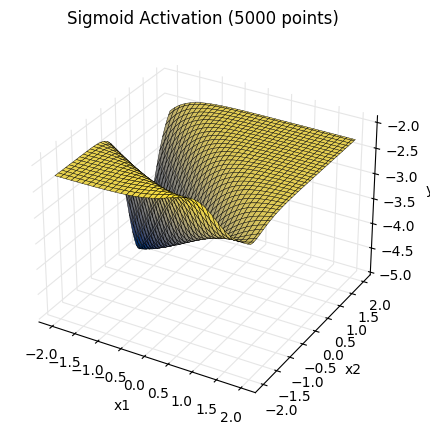

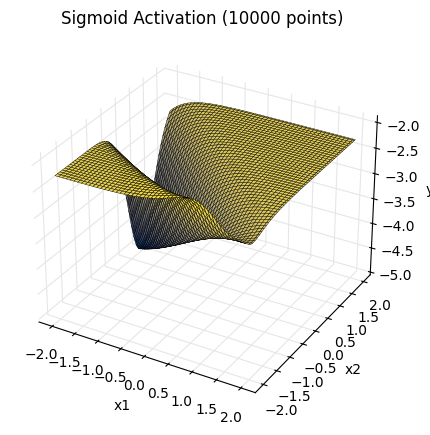

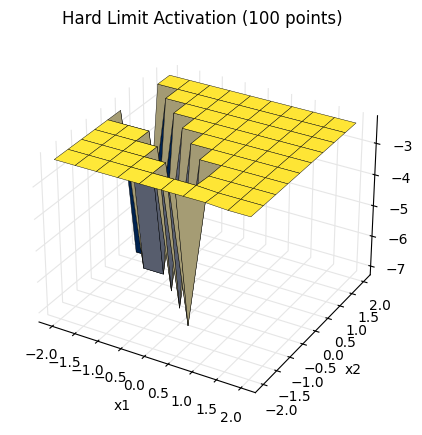

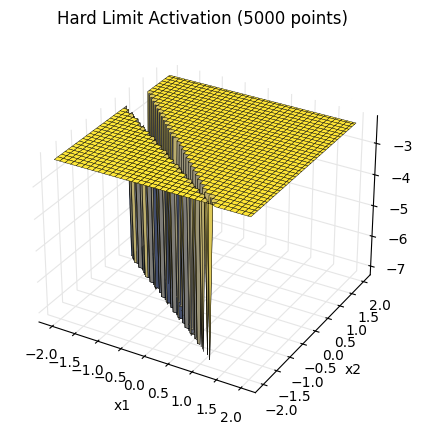

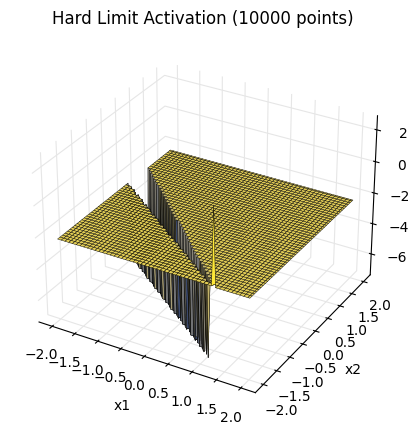

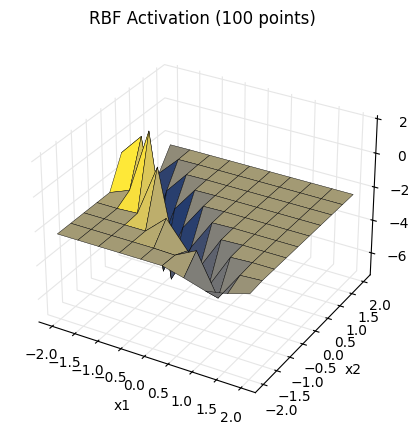

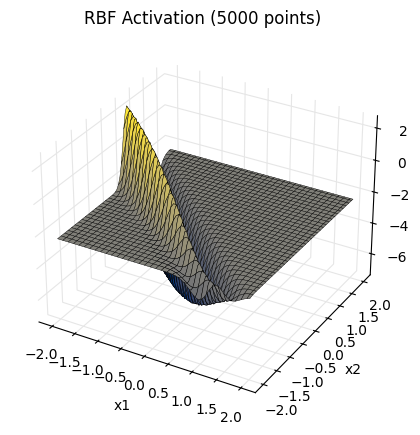

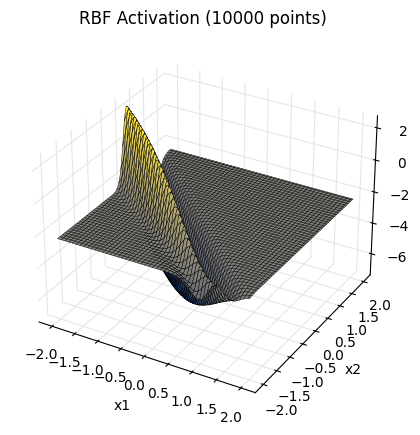

In [9]:

# Run for sigmoid, hard limit, radial basis
for act, name in [(sigmoid, "Sigmoid"), (hard_limit, "Hard Limit"), (radial_basis, "RBF")]:
    for n in [100, 5000, 10000]:
        plot_surface(n, act, f"{name} Activation ({n} points)")